In [2]:
import pandas as pd
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt


load_dotenv()
db_path = f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"


In [3]:
engine = create_engine(db_path)

query = """
SELECT f.*, d.gender, d.senior_citizen, d.partner, d.dependents
FROM fact_churn f
JOIN dim_customer d ON f.customer_sk = d.customer_sk
"""

df = pd.read_sql(query,engine)

df_model = pd.get_dummies(df, columns = ['gender', 'partner', 'dependents', 'senior_citizen'], drop_first=True)
df_model = df_model.astype(int)
print(df_model.head())

   churn_sk  customer_sk  tenure  monthly_charges  total_charges  is_churned  \
0         1          469       1               29             29           0   
1         2         4801      34               56           1889           0   
2         3         1416       2               53            108           1   
3         4         3798      45               42           1840           0   
4         5         3611       2               70            151           1   

   gender_Male  partner_Yes  dependents_Yes  senior_citizen_1  
0            0            1               0                 0  
1            1            0               0                 0  
2            1            0               0                 0  
3            1            0               0                 0  
4            0            0               0                 0  


In [4]:
X = df_model.drop(['churn_sk', 'customer_sk', 'is_churned'], axis = 1)
y = df_model['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

clf = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1029
           1       0.53      0.61      0.57       380

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.76      0.75      0.76      1409



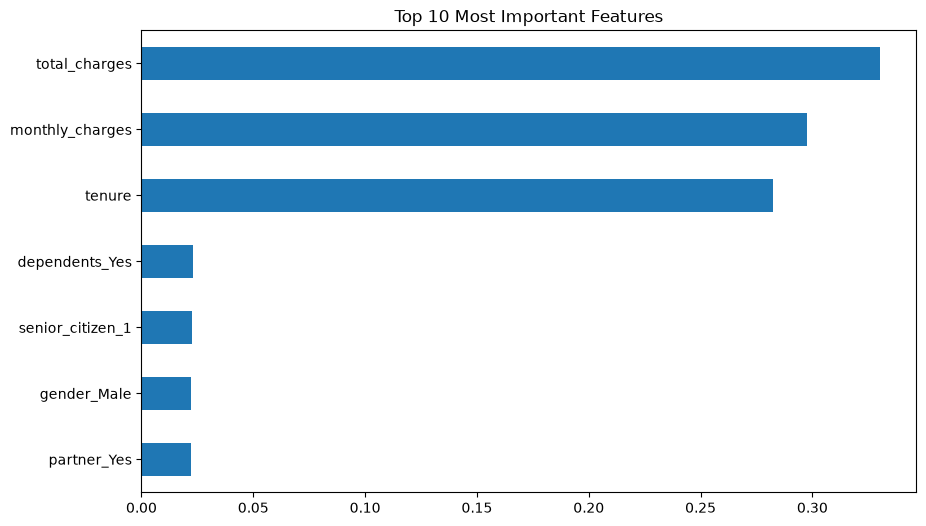

total_charges       0.330029
monthly_charges     0.297739
tenure              0.282552
dependents_Yes      0.022817
senior_citizen_1    0.022563
gender_Male         0.022255
partner_Yes         0.022044
dtype: float64


In [5]:
feat_importances = pd.Series(clf.feature_importances_, index= X.columns)

plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind = 'barh')
plt.title('Top 10 Most Important Features')
plt.gca().yaxis.set_inverted(True)
plt.show()

print(feat_importances.sort_values(ascending = False))

In [6]:
top_features = ['total_charges', 'monthly_charges', 'tenure']
X_pruned = X[top_features]

X_train_p, X_test_p, y_train, y_test = train_test_split(X_pruned, y, test_size = 0.2, random_state=42)

clf_pruned = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf_pruned.fit(X_train_p, y_train)

y_pred_p = clf_pruned.predict(X_test_p)
print(classification_report(y_test, y_pred_p))

              precision    recall  f1-score   support

           0       0.85      0.78      0.81      1029
           1       0.51      0.62      0.56       380

    accuracy                           0.74      1409
   macro avg       0.68      0.70      0.69      1409
weighted avg       0.76      0.74      0.74      1409



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 200],
              'max_depth': [None, 10, 20],
              'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state = 42 ), param_grid, cv = 5, scoring = 'f1')

grid_search.fit(X_train_p, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1-score:", grid_search.best_score_)



Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
Best F1-score: 0.5867955248669852


: 

In [ ]:
import shap 

explainer = shap.TreeExplainer(clf)

shap_values = explainer.shap_values(X_test_p)

shap.summary_plot(shap_values[1], X_test_p)